# Example 7: Ground-Station Orbit Determination for a Lunar Satellite

This tutorial estimates a lunar satellite trajectory from Earth-based range and range-rate tracking, and doubles as a tour of LuPNT's **agent-based simulation architecture**. The scenario is assembled from first-class agents sharing a common environment:

- a **`World`** — the shared, read-only physical environment (epoch, integration frame, force model). Truth and the estimator draw their dynamics from this one object by default, so there is no truth/filter model mismatch (the manager app can optionally override its batch and/or sequential filter dynamics via a `filter_dynamics:` block to study a deliberate mismatch).
- a **`Satellite`** agent (`sat`) that self-propagates the ELFO truth trajectory.
- three **`GroundStation`** agents (Goldstone `DSS14`, Canberra `DSS43`, Madrid `DSS63`), each running a **`GroundStationTrackingApp`** (a *sensor*) that generates visibility-gated range/range-rate observations and pushes them to the manager.
- a **`GroundStationManager`** agent (`gs_manager`, the *estimator*) whose **`GroundStationManagerApp`** aggregates all stations' observations and runs the centralized **batch least-squares** filter, then a **square-root information filter (SRIF) and smoother**.

The 36-hour orbit-determination arc is compute-heavy, so we run it **once, in a standalone script**, and cache the results as CSV. This notebook just reads those CSVs and plots — keeping it fast and reproducible.

> **Run the simulation first** (from the repo root):
> ```bash
> python python/examples/ex7_run_odts.py
> ```
> This writes CSVs to `output/python_examples/ex7_data/`. Re-run it (optionally with `--duration`) whenever you change the scenario in `configs/ground_station_odts.yaml`.


## Modeling the signal-path and station-location delays

The three tracking stations are on **Earth**, so their range and range-rate
observations of the lunar satellite are not purely geometric. This scenario adds
the dominant physical delays to each station's **truth** observable
(`apply_*` keys in `configs/ground_station_odts.yaml`):

- **Troposphere** — the neutral-atmosphere delay (Saastamoinen), ~2.4 m at zenith
  and ~14 m near the 10° elevation mask.
- **Ionosphere** — a dispersive charged-particle delay (thin-shell VTEC), sub-meter
  at X-band but larger at low elevation.
- **Shapiro delay** — the relativistic light-time delay in the Sun's and Earth's
  gravity, a few meters.
- **Solid Earth tide** — the Sun/Moon tidal deformation displaces each station by
  up to ~0.3 m, biasing both range and range-rate.

Left unmodeled these would show up as a large tracking residual, so the
`GroundStationManagerApp` **estimator models them back out**. The deterministic
terms are removed in full — the Shapiro delay is subtracted from the predicted
range (`model_shapiro`) and the solid-tide displacement is applied to the modeled
station position (`model_solid_earth_tide`). The atmospheric terms cannot be known
exactly, so only a **calibrated fraction** is removed
(`troposphere_cancel_fraction`, `ionosphere_cancel_fraction`, here 0.8), and the
**uncancelled remainder inflates the range measurement noise**
(`residual_delay_noise_scale`) so the biased low-elevation observations are
down-weighted. The result: the truth data is realistic, yet the orbit solution
stays close to the ideal geometric-only case.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the CSVs written by ex7_run_odts.py (output/python_examples/ex7_data/).
DATA = None
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "output/python_examples/ex7_data/meta.json").exists():
        DATA = _b / "output/python_examples/ex7_data"
        break
    if (_b / "ex7_data/meta.json").exists():
        DATA = _b / "ex7_data"
        break
assert DATA is not None, "Run `python python/examples/ex7_run_odts.py` first to generate ex7_data/."

meta = json.load(open(DATA / "meta.json"))
grid = pd.read_csv(DATA / "grid.csv")
iters = pd.read_csv(DATA / "iterations.csv")
elevation = pd.read_csv(DATA / "elevation.csv")
measurements = pd.read_csv(DATA / "measurements.csv")
epoch_sol = pd.read_csv(DATA / "epoch_solution.csv").set_index("which")
covariance = pd.read_csv(DATA / "covariance.csv", index_col=0).values

SECS_HOUR = 3600.0
comp = ["rx", "ry", "rz", "vx", "vy", "vz"]
station_order = meta["station_order"]
station_labels = meta["station_labels"]
station_colors = {"DSS14": "steelblue", "DSS43": "darkorange", "DSS63": "seagreen"}
elev_mask = meta["elevation_mask_deg"]

t_grid = grid["t_s"].values
t_hrs = t_grid / SECS_HOUR
N = len(t_grid)

def block(prefix, ncol):
    if ncol == 6:
        return grid[[f"{prefix}_{c}" for c in comp]].values
    cols = [f"{prefix}_{r}{c}" for r in range(6) for c in range(6)]
    return grid[cols].values.reshape(N, 6, 6)

truth = block("tr", 6)
est = block("es", 6)
est_cov = block("ec", 36)

print(f"duration={meta['duration']}  epochs={N}  measurements={meta['num_measurements']}")
print(f"converged={meta['converged']}  iterations={meta['num_iterations']}")

duration=36:00:00  epochs=433  measurements=627
converged=True  iterations=5


## 1. Visibility Analysis

Each `GroundStationTrackingApp` records the satellite's topocentric elevation at every step. Shaded bands mark the passes above the mask that produced measurements.


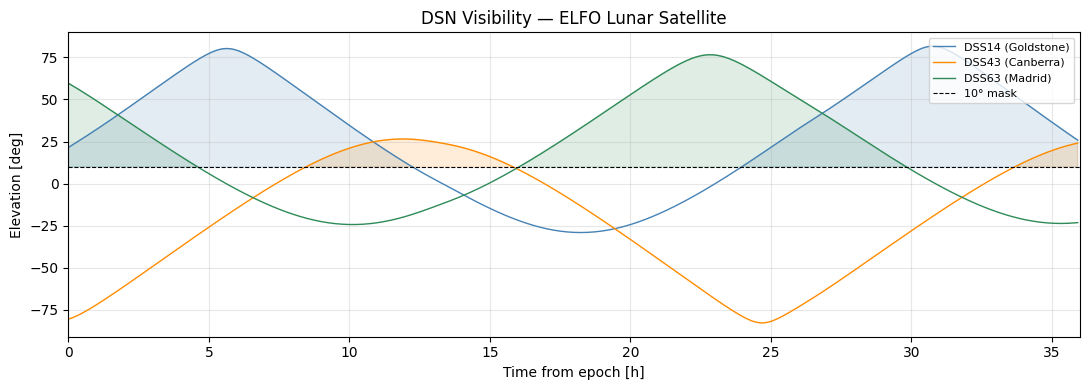

DSS14 (Goldstone)      291/432 epochs visible ( 67.4%)
DSS43 (Canberra)       115/432 epochs visible ( 26.6%)
DSS63 (Madrid)         221/432 epochs visible ( 51.2%)


In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
for n in station_order:
    e = elevation[elevation.station == n]
    et, ed = e.t_s.values / SECS_HOUR, e.elevation_deg.values
    c = station_colors.get(n, "gray")
    ax.plot(et, ed, lw=1.0, color=c, label=station_labels[n])
    ax.fill_between(et, ed, elev_mask, where=ed > elev_mask, color=c, alpha=0.15)
ax.axhline(elev_mask, color="k", ls="--", lw=0.8, label=f"{elev_mask:.0f}\N{DEGREE SIGN} mask")
ax.set_xlabel("Time from epoch [h]"); ax.set_ylabel("Elevation [deg]")
ax.set_title("DSN Visibility — ELFO Lunar Satellite")
ax.set_xlim(0, t_hrs[-1]); ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

for n in station_order:
    ed = elevation[elevation.station == n].elevation_deg.values
    n_vis = int(np.sum(ed > elev_mask))
    print(f"{station_labels[n]:20s}  {n_vis:4d}/{len(ed)} epochs visible ({100*n_vis/len(ed):5.1f}%)")

## 2. Simulated Range and Range-Rate Measurements

Each station reports only its above-the-mask observations to the manager.


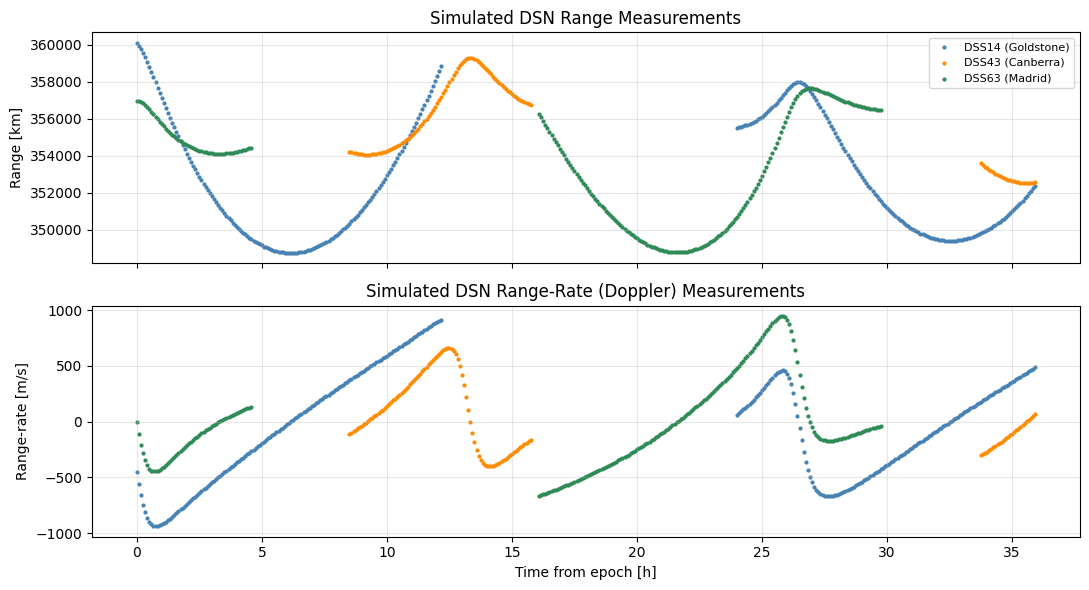

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for n in station_order:
    m = measurements[measurements.station == n]
    mt = m.t_s.values / SECS_HOUR
    axes[0].scatter(mt, m.range_m.values / 1e3, s=4, color=station_colors.get(n), label=station_labels[n])
    axes[1].scatter(mt, m.range_rate_mps.values, s=4, color=station_colors.get(n))
axes[0].set_ylabel("Range [km]"); axes[0].set_title("Simulated DSN Range Measurements")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel("Range-rate [m/s]"); axes[1].set_xlabel("Time from epoch [h]")
axes[1].set_title("Simulated DSN Range-Rate (Doppler) Measurements"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Batch Filter Convergence

The manager's batch filter is a weighted least-squares over **all three stations'** measurements, starting from the deliberately perturbed a-priori state.


In [4]:
x0_true = epoch_sol.loc["true"].values
x0_guess = epoch_sol.loc["initial_guess"].values
pos0 = np.linalg.norm(x0_guess[:3] - x0_true[:3])
vel0 = np.linalg.norm(x0_guess[3:] - x0_true[3:])
print(f"Initial position error: {pos0:.1f} m   Initial velocity error: {vel0:.3f} m/s\n")
for _, row in iters.iterrows():
    print(f"iter {int(row['iter'])}: rms(rho)={row['rms_range_m']:8.3f} m  "
          f"rms(rho_dot)={row['rms_range_rate_mps']:9.6f} m/s  "
          f"|pos_err|={row['pos_error_m']:9.3f} m  |vel_err|={row['vel_error_mps']:9.6f} m/s  "
          f"weighted_rms={row['weighted_rms']:8.3f}")

Initial position error: 1149.0 m   Initial velocity error: 0.468 m/s

iter 0: rms(rho)=116286.712 m  rms(rho_dot)=28.525823 m/s  |pos_err|= 1149.038 m  |vel_err|= 0.467796 m/s  weighted_rms=21768.417
iter 1: rms(rho)=12811.708 m  rms(rho_dot)= 1.131342 m/s  |pos_err|=16144.462 m  |vel_err|=10.538861 m/s  weighted_rms=1204.959
iter 2: rms(rho)=1791.366 m  rms(rho_dot)= 0.432610 m/s  |pos_err|=   24.444 m  |vel_err|= 0.038478 m/s  weighted_rms= 330.871
iter 3: rms(rho)=  10.476 m  rms(rho_dot)= 0.001013 m/s  |pos_err|=    3.958 m  |vel_err|= 0.002238 m/s  weighted_rms=   1.028
iter 4: rms(rho)=  10.236 m  rms(rho_dot)= 0.000959 m/s  |pos_err|=    1.639 m  |vel_err|= 0.000711 m/s  weighted_rms=   0.989


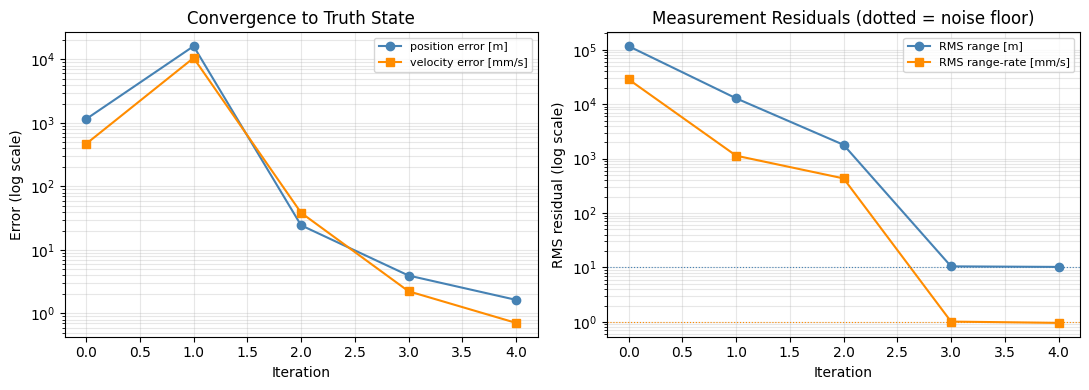

In [5]:
it = iters["iter"].values
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(it, iters.pos_error_m, "o-", color="steelblue", label="position error [m]")
axes[0].semilogy(it, iters.vel_error_mps * 1e3, "s-", color="darkorange", label="velocity error [mm/s]")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Error (log scale)")
axes[0].set_title("Convergence to Truth State"); axes[0].legend(fontsize=8)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(it, iters.rms_range_m, "o-", color="steelblue", label="RMS range [m]")
axes[1].semilogy(it, iters.rms_range_rate_mps * 1e3, "s-", color="darkorange", label="RMS range-rate [mm/s]")
axes[1].axhline(meta["range_sigma_m"], color="steelblue", ls=":", lw=0.8)
axes[1].axhline(meta["range_rate_sigma_mps"] * 1e3, color="darkorange", ls=":", lw=0.8)
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("RMS residual (log scale)")
axes[1].set_title("Measurement Residuals (dotted = noise floor)"); axes[1].legend(fontsize=8)
axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Final Solution and Formal Covariance


In [6]:
x0_est = epoch_sol.loc["estimated"].values
sigma = np.sqrt(np.diag(covariance))
print("Estimated epoch state (world frame):")
print(f"  r0 = {x0_est[:3]} m")
print(f"  v0 = {x0_est[3:]} m/s\n")
print(f"Final position error vs. truth: {np.linalg.norm(x0_est[:3]-x0_true[:3]):.3f} m "
      f"(formal 1-sigma: {np.linalg.norm(sigma[:3]):.3f} m)")
print(f"Final velocity error vs. truth: {np.linalg.norm(x0_est[3:]-x0_true[3:]):.6f} m/s "
      f"(formal 1-sigma: {np.linalg.norm(sigma[3:]):.6f} m/s)")

Estimated epoch state (world frame):
  r0 = [ 410799.87968233  178482.33127857 2577940.56327328] m
  v0 = [-1636.08827673   520.32817823   224.68962343] m/s

Final position error vs. truth: 1.639 m (formal 1-sigma: 1.877 m)
Final velocity error vs. truth: 0.000711 m/s (formal 1-sigma: 0.000973 m/s)


## 5. Estimate Error in the RTN Frame with Formal Covariance

We rotate the estimate error into the radial/transverse/normal (RTN) frame of the true orbit and overlay the batch formal covariance propagated along the arc, `P(t_i) = Phi(t_i, t0) P0 Phi(t_i, t0)^T`.


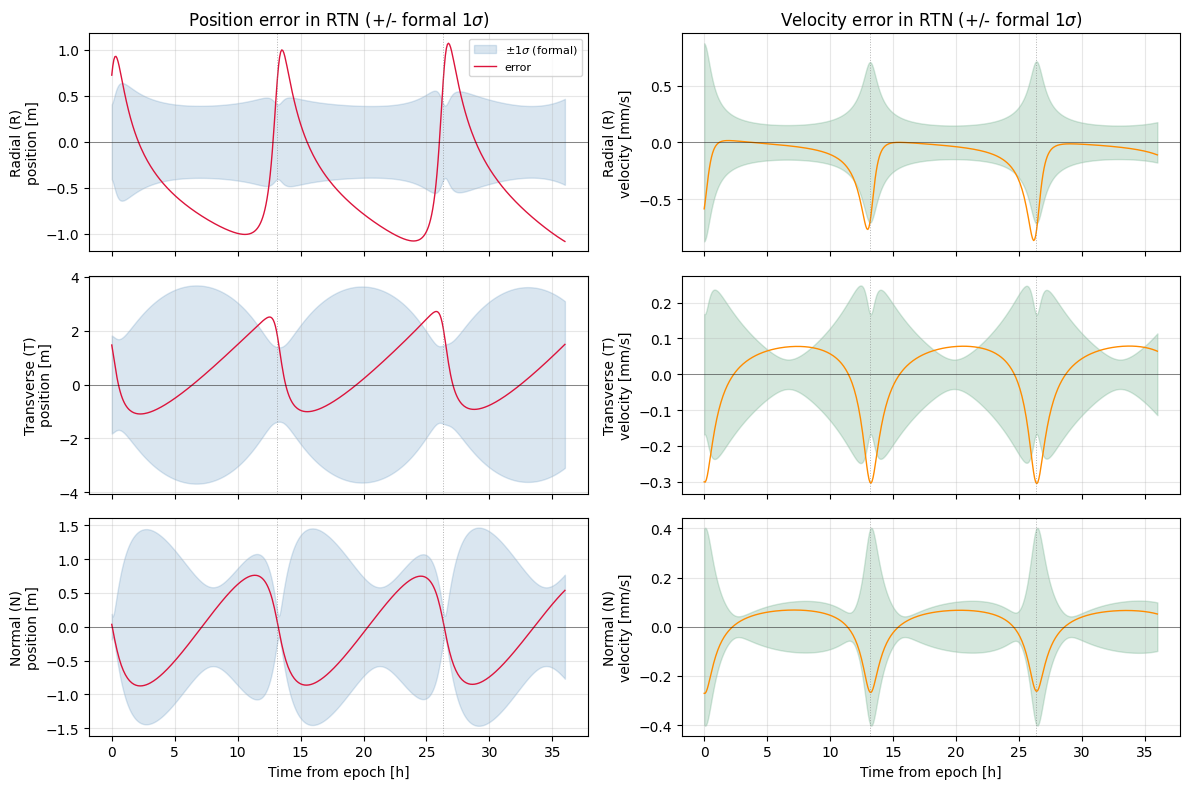

In [7]:
r_true, v_true = truth[:, :3], truth[:, 3:]
R_hat = r_true / np.linalg.norm(r_true, axis=1, keepdims=True)
h = np.cross(r_true, v_true)
N_hat = h / np.linalg.norm(h, axis=1, keepdims=True)
T_hat = np.cross(N_hat, R_hat)
Q = np.stack([R_hat, T_hat, N_hat], axis=1)

dpos_rtn = np.einsum("nij,nj->ni", Q, est[:, :3] - truth[:, :3])
dvel_rtn = np.einsum("nij,nj->ni", Q, est[:, 3:] - truth[:, 3:])
Prr = np.einsum("nij,njk,nlk->nil", Q, est_cov[:, :3, :3], Q)
Pvv = np.einsum("nij,njk,nlk->nil", Q, est_cov[:, 3:, 3:], Q)
sig_pos_rtn = np.sqrt(np.diagonal(Prr, axis1=1, axis2=2))
sig_vel_rtn = np.sqrt(np.diagonal(Pvv, axis1=1, axis2=2))

r_mag = np.linalg.norm(r_true, axis=1)
peri = np.where((r_mag[1:-1] < r_mag[:-2]) & (r_mag[1:-1] < r_mag[2:]))[0] + 1
labels = ["Radial (R)", "Transverse (T)", "Normal (N)"]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for k in range(3):
    axp = axes[k, 0]
    axp.fill_between(t_hrs, -sig_pos_rtn[:, k], sig_pos_rtn[:, k], color="steelblue", alpha=0.20,
                     label=r"$\pm 1\sigma$ (formal)")
    axp.plot(t_hrs, dpos_rtn[:, k], color="crimson", lw=1.0, label="error")
    axp.axhline(0.0, color="k", lw=0.6, alpha=0.5)
    axp.set_ylabel(f"{labels[k]}\nposition [m]"); axp.grid(True, alpha=0.3)
    axv = axes[k, 1]
    axv.fill_between(t_hrs, -sig_vel_rtn[:, k]*1e3, sig_vel_rtn[:, k]*1e3, color="seagreen", alpha=0.20,
                     label=r"$\pm 1\sigma$ (formal)")
    axv.plot(t_hrs, dvel_rtn[:, k]*1e3, color="darkorange", lw=1.0, label="error")
    axv.axhline(0.0, color="k", lw=0.6, alpha=0.5)
    axv.set_ylabel(f"{labels[k]}\nvelocity [mm/s]"); axv.grid(True, alpha=0.3)
for ax in axes.ravel():
    for p in peri:
        ax.axvline(t_hrs[p], color="gray", ls=":", lw=0.7, alpha=0.6)
axes[0, 0].set_title("Position error in RTN (+/- formal 1$\\sigma$)")
axes[0, 1].set_title("Velocity error in RTN (+/- formal 1$\\sigma$)")
axes[2, 0].set_xlabel("Time from epoch [h]"); axes[2, 1].set_xlabel("Time from epoch [h]")
axes[0, 0].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## 6. Square-Root Information Filter and Smoother

The batch covariance (`Phi P0 Phi^T`) is optimistic. The manager also runs a **square-root information filter** (with white-noise-acceleration process noise) plus a **fixed-interval smoother**: the forward filter grows through the untracked apoapsis coasts, while the smoother uses data on both sides of every epoch and stays bounded — a realistic, honest uncertainty.


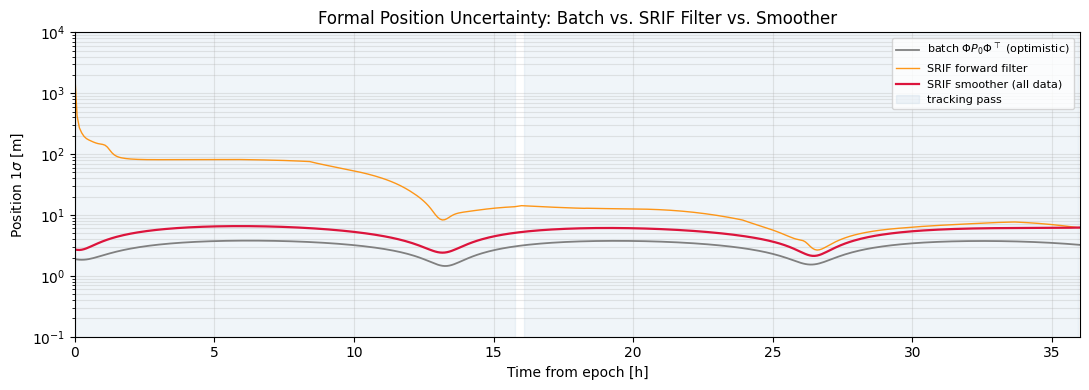

In [8]:
def pos_sigma(cov3d):
    return np.sqrt(cov3d[:, 0, 0] + cov3d[:, 1, 1] + cov3d[:, 2, 2])

srif_filt_cov = block("sfc", 36)
srif_smooth_cov = block("ssc", 36)

dt = t_grid[1] - t_grid[0]
tracked = np.zeros(N, dtype=bool)
midx = np.clip(np.round(measurements.t_s.values / dt).astype(int), 0, N - 1)
tracked[midx] = True

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(t_hrs, pos_sigma(est_cov), color="gray", lw=1.3, label=r"batch $\Phi P_0 \Phi^\top$ (optimistic)")
ax.semilogy(t_hrs, pos_sigma(srif_filt_cov), color="darkorange", lw=1.0, alpha=0.9, label="SRIF forward filter")
ax.semilogy(t_hrs, pos_sigma(srif_smooth_cov), color="crimson", lw=1.6, label="SRIF smoother (all data)")
ax.fill_between(t_hrs, 1e-3, 1e5, where=tracked, color="steelblue", alpha=0.08, label="tracking pass", step="mid")
ax.set_xlabel("Time from epoch [h]"); ax.set_ylabel(r"Position $1\sigma$ [m]")
ax.set_ylim(1e-1, 1e4); ax.set_xlim(0, t_hrs[-1])
ax.set_title("Formal Position Uncertainty: Batch vs. SRIF Filter vs. Smoother")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Smoother Error and Covariance in the RTN Frame

The smoothed estimate error, with the smoother covariance tube (solid) against the batch tube (dashed) from Section 5.


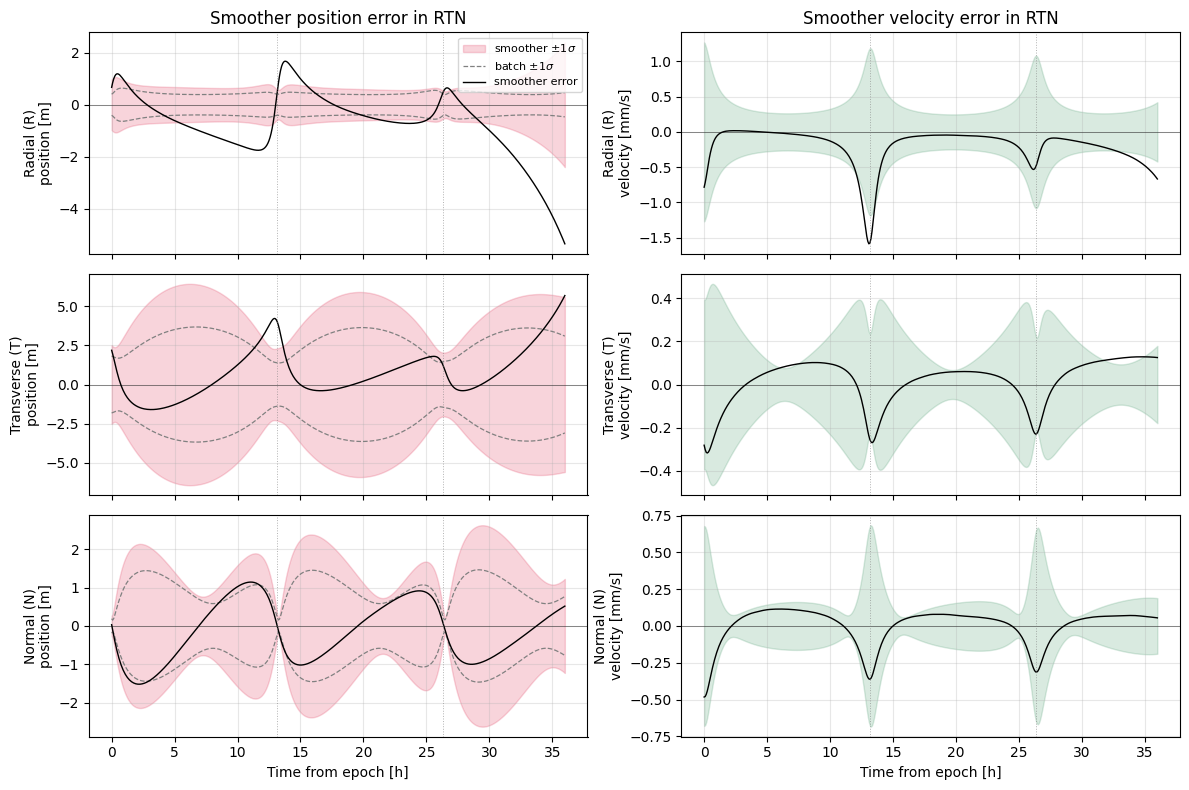

In [9]:
sm_state = block("ss", 6)
sm_cov = block("ssc", 36)
dpos_s = np.einsum("nij,nj->ni", Q, sm_state[:, :3] - truth[:, :3])
dvel_s = np.einsum("nij,nj->ni", Q, sm_state[:, 3:] - truth[:, 3:])
Prr_s = np.einsum("nij,njk,nlk->nil", Q, sm_cov[:, :3, :3], Q)
Pvv_s = np.einsum("nij,njk,nlk->nil", Q, sm_cov[:, 3:, 3:], Q)
sig_pos_s = np.sqrt(np.diagonal(Prr_s, axis1=1, axis2=2))
sig_vel_s = np.sqrt(np.diagonal(Pvv_s, axis1=1, axis2=2))

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for k in range(3):
    axp = axes[k, 0]
    axp.fill_between(t_hrs, -sig_pos_s[:, k], sig_pos_s[:, k], color="crimson", alpha=0.18, label=r"smoother $\pm1\sigma$")
    axp.plot(t_hrs, sig_pos_rtn[:, k], color="gray", ls="--", lw=0.9, label=r"batch $\pm1\sigma$")
    axp.plot(t_hrs, -sig_pos_rtn[:, k], color="gray", ls="--", lw=0.9)
    axp.plot(t_hrs, dpos_s[:, k], color="black", lw=1.0, label="smoother error")
    axp.axhline(0.0, color="k", lw=0.6, alpha=0.5)
    axp.set_ylabel(f"{labels[k]}\nposition [m]"); axp.grid(True, alpha=0.3)
    axv = axes[k, 1]
    axv.fill_between(t_hrs, -sig_vel_s[:, k]*1e3, sig_vel_s[:, k]*1e3, color="seagreen", alpha=0.18, label=r"smoother $\pm1\sigma$")
    axv.plot(t_hrs, dvel_s[:, k]*1e3, color="black", lw=1.0, label="smoother error")
    axv.axhline(0.0, color="k", lw=0.6, alpha=0.5)
    axv.set_ylabel(f"{labels[k]}\nvelocity [mm/s]"); axv.grid(True, alpha=0.3)
for ax in axes.ravel():
    for p in peri:
        ax.axvline(t_hrs[p], color="gray", ls=":", lw=0.7, alpha=0.6)
axes[0, 0].set_title("Smoother position error in RTN"); axes[0, 1].set_title("Smoother velocity error in RTN")
axes[2, 0].set_xlabel("Time from epoch [h]"); axes[2, 1].set_xlabel("Time from epoch [h]")
axes[0, 0].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()